# Evaluation — claude-opus-4-8 (Anthropic)

## Experiment metadata

| | Batch | Whole-doc | Option A — PDF Direct |
|---|---|---|---|
| **Prompt strategy** | 10 blocks/request · 3-block sliding context window | All blocks in 1 request · model sees full document | Raw PDF sent to Claude — no pdfplumber · Claude extracts + classifies |
| **Input files** | `data/llmlabeled/sampleN_claude-opus-4-8_batch.json` | `data/llmlabeled/sampleN_claude-opus-4-8_whole_doc.json` | `data/llmlabeled/sampleN_claude-opus-4-8_pdf.json` |
| **Regenerate** | `dmpbridge document.pdf --provider anthropic` | `dmpbridge-wholedoc --provider anthropic` | `dmpbridge-pdf --model claude-opus-4-8` |
| **Provider** | Anthropic API | Anthropic API | Anthropic API (PDF vision) |
| **Block granularity** | Line-level (pdfplumber) | Line-level (pdfplumber) | Paragraph-level (Claude reads PDF) |
| **Bounding boxes** | Yes | Yes | No |

**Labels (5):** `title` · `section.title` · `section.description` · `question.text` · `answer.text`  
**Evaluation:** block-level accuracy + F1 against `data/manuallabeled/sampleN_dmp.json`  — no new files are written.

---

## Sections
1. Accuracy summary — per-sample table and batch vs whole-doc delta
2. Per-sample accuracy — side-by-side bar chart
3. Confusion matrix — raw counts and row-normalised recall
4. Precision / Recall / F1 — per label with batch vs whole-doc comparison
5. Mislabeled blocks — error breakdown and full detail table
6. **Option A — PDF Direct** — accuracy, block count, F1, and error analysis

In [1]:
MODEL_NAME    = "claude-opus-4-8"
MODEL_DISPLAY = "claude-opus-4-8"
COLOR_BATCH   = "#7c3aed"   # purple
COLOR_WHOLE   = "#c084fc"   # light purple
COLOR_PDF     = "#059669"   # green
CMAP_BATCH    = "Purples"
CMAP_WHOLE    = "RdPu"
CMAP_PDF      = "Greens"

In [2]:
from dmpbridge.evaluate import (
    extract_gold, evaluate_sample, match,
    LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH,
    load_method, compute_f1_rows, gold_metrics,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True,
    "figure.dpi":120,
})

# File tags: sampleN_{tag}.json
df_b, conf_b, errs_b = load_method(f"{MODEL_NAME}_batch")
df_w, conf_w, errs_w = load_method(f"{MODEL_NAME}_whole_doc")
df_p, conf_p, errs_p = load_method(f"{MODEL_NAME}_pdf")

WHOLEDOC_AVAILABLE = df_w is not None and not df_w.empty
PDF_AVAILABLE      = df_p is not None and not df_p.empty

tc_b, tn_b = int(df_b["correct"].sum()), int(df_b["total"].sum())
print(f"Batch      ({MODEL_NAME}_batch)     : {tc_b}/{tn_b} ({tc_b/tn_b*100:.1f}%)")
if WHOLEDOC_AVAILABLE:
    tc_w, tn_w = int(df_w["correct"].sum()), int(df_w["total"].sum())
    print(f"Whole-doc  ({MODEL_NAME}_whole_doc) : {tc_w}/{tn_w} ({tc_w/tn_w*100:.1f}%)")
else:
    print(f"Whole-doc  : not available — run: dmpbridge-wholedoc --provider anthropic --model {MODEL_DISPLAY}")
if PDF_AVAILABLE:
    tc_p, tn_p = int(df_p["correct"].sum()), int(df_p["total"].sum())
    print(f"PDF-direct ({MODEL_NAME}_pdf)       : {tc_p}/{tn_p} ({tc_p/tn_p*100:.1f}%)  [{tn_p} blocks vs {tn_b} pdfplumber]")
else:
    print(f"PDF-direct : not available — run: dmpbridge-pdf --model {MODEL_DISPLAY}")

Batch      (claude-opus-4-8_batch)     : 703/741 (94.9%)
Whole-doc  (claude-opus-4-8_whole_doc) : 718/741 (96.9%)
PDF-direct (claude-opus-4-8_pdf)       : 193/203 (95.1%)  [203 blocks vs 741 pdfplumber]


## 1 — Accuracy summary

- **Accuracy** = blocks where the predicted label exactly matches gold.
- **Delta** = whole-doc minus batched. Positive = whole-doc is better on that sample.
- A single bad sample can pull the overall number down significantly — check the per-sample view next.

In [3]:
def print_table(df, label):
    hdr = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
    print(f"  {label}")
    print("  " + "-" * len(hdr))
    for row in df.itertuples():
        print(f"  {row.sample:<12}  {row.total:>5}  {row.correct:>7}  "
              f"{row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
    print("  " + "-" * len(hdr))
    tn, tc = df["total"].sum(), df["correct"].sum()
    print(f"  {'TOTAL':<12}  {tn:>5}  {tc:>7}  {tn-tc:>6}  {tc/tn*100:>7.1f}%  {tc}/{tn}\n")

print_table(df_b, f"Batched — {MODEL_NAME}")

if WHOLEDOC_AVAILABLE:
    print_table(df_w, f"Whole-doc — {MODEL_NAME}")

if PDF_AVAILABLE:
    print_table(df_p, f"PDF-direct — {MODEL_NAME} (Option A)")

# ── Delta comparison across all available strategies ──────────────────────────
if WHOLEDOC_AVAILABLE:
    merged = df_b[["sample","accuracy"]].rename(columns={"accuracy":"batch"}).merge(
             df_w[["sample","accuracy"]].rename(columns={"accuracy":"whole"}), on="sample")
    merged["Δ whole−batch"] = merged["whole"] - merged["batch"]

    if PDF_AVAILABLE:
        merged = merged.merge(
            df_p[["sample","accuracy"]].rename(columns={"accuracy":"pdf"}), on="sample")
        merged["Δ pdf−whole"] = merged["pdf"] - merged["whole"]
        print(f"  {'Sample':<12}  {'Batch':>8}  {'Whole-doc':>10}  {'PDF-direct':>11}  {'Δ whole−batch':>14}  {'Δ pdf−whole':>12}")
        print("  " + "-" * 72)
        for _, r in merged.iterrows():
            s1 = ('+' if r['Δ whole−batch'] >= 0 else '') + f"{r['Δ whole−batch']*100:.1f}%"
            s2 = ('+' if r['Δ pdf−whole']   >= 0 else '') + f"{r['Δ pdf−whole']*100:.1f}%"
            print(f"  {r['sample']:<12}  {r['batch']*100:>7.1f}%  {r['whole']*100:>9.1f}%  "
                  f"{r['pdf']*100:>10.1f}%  {s1:>14}  {s2:>12}")
        tb = df_b['correct'].sum() / df_b['total'].sum()
        tw = df_w['correct'].sum() / df_w['total'].sum()
        tp = df_p['correct'].sum() / df_p['total'].sum()
        s1 = ('+' if tw-tb >= 0 else '') + f"{(tw-tb)*100:.1f}%"
        s2 = ('+' if tp-tw >= 0 else '') + f"{(tp-tw)*100:.1f}%"
        print("  " + "-" * 72)
        print(f"  {'OVERALL':<12}  {tb*100:>7.1f}%  {tw*100:>9.1f}%  {tp*100:>10.1f}%  {s1:>14}  {s2:>12}")
    else:
        print(f"  {'Sample':<12}  {'Batched':>9}  {'Whole-doc':>10}  {'Delta':>8}")
        print("  " + "-" * 46)
        for _, r in merged.iterrows():
            sign = '+' if r['Δ whole−batch'] >= 0 else ''
            print(f"  {r['sample']:<12}  {r['batch']*100:>8.1f}%  {r['whole']*100:>9.1f}%  {sign}{r['Δ whole−batch']*100:>6.1f}%")
        tb = df_b['correct'].sum() / df_b['total'].sum()
        tw = df_w['correct'].sum() / df_w['total'].sum()
        sign = '+' if (tw - tb) >= 0 else ''
        print("  " + "-" * 46)
        print(f"  {'OVERALL':<12}  {tb*100:>8.1f}%  {tw*100:>9.1f}%  {sign}{(tw-tb)*100:>6.1f}%")

# ── Gold-matched precision (why block accuracy can mislead) ───────────────────
# Block accuracy = correct / all blocks. But pdfplumber (741 blocks) and PDF-direct
# (203 blocks) work at different granularities, so the denominators are not comparable.
# This table restricts the denominator to blocks that actually matched a gold item,
# revealing each strategy's label precision on content it DID extract.
if PDF_AVAILABLE:
    print("\n\n  ── Gold-matched precision (blocks that matched a manual-label item) ──\n")
    print(f"  {'Strategy':<14}  {'Correct':>8}  {'Matched':>8}  {'All blocks':>11}  {'Gold prec':>10}  {'Block acc':>10}")
    print("  " + "-" * 68)
    for strat_label, conf, df_strat in [
        ("Batch",      conf_b, df_b),
        ("Whole-doc",  conf_w, df_w),
        ("PDF-direct", conf_p, df_p),
    ]:
        correct, covered, matched = gold_metrics(conf)
        all_blocks = int(df_strat["total"].sum())
        gold_prec  = correct / matched     if matched     else 0
        block_acc  = correct / all_blocks  if all_blocks  else 0
        print(f"  {strat_label:<14}  {correct:>8}  {matched:>8}  {all_blocks:>11}  {gold_prec*100:>9.1f}%  {block_acc*100:>9.1f}%")
    print()
    print("  Gold prec  = Correct / Matched blocks  (precision among blocks that cover manual content)")
    print("  Block acc  = Correct / All blocks      (standard metric — penalises strategies with many blocks)")
    print()
    print("  PDF-direct extracts ~27% as many blocks as pdfplumber, so its block-acc denominator is smaller.")
    print("  Gold precision removes that bias: all 3 strategies show 96–100% on the content they touch.")

  Batched — claude-opus-4-8
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      149      23     86.6%  149/172
  sample3          69       69       0    100.0%  69/69
  sample4          78       78       0    100.0%  78/78
  sample5          86       80       6     93.0%  80/86
  sample6          29       21       8     72.4%  21/29
  sample7          17       16       1     94.1%  16/17
  sample8          59       59       0    100.0%  59/59
  sample9          85       85       0    100.0%  85/85
  sample10         68       68       0    100.0%  68/68
  -------------------------------------------------------
  TOTAL           741      703      38     94.9%  703/741

  Whole-doc — claude-opus-4-8
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      166       6     96.5%  166/172
  sample3          69       69   

## 2 — Per-sample accuracy

Hatched bars = whole-doc variant.  
Large gaps between the two methods on the same sample = documents where batching loses structural context.

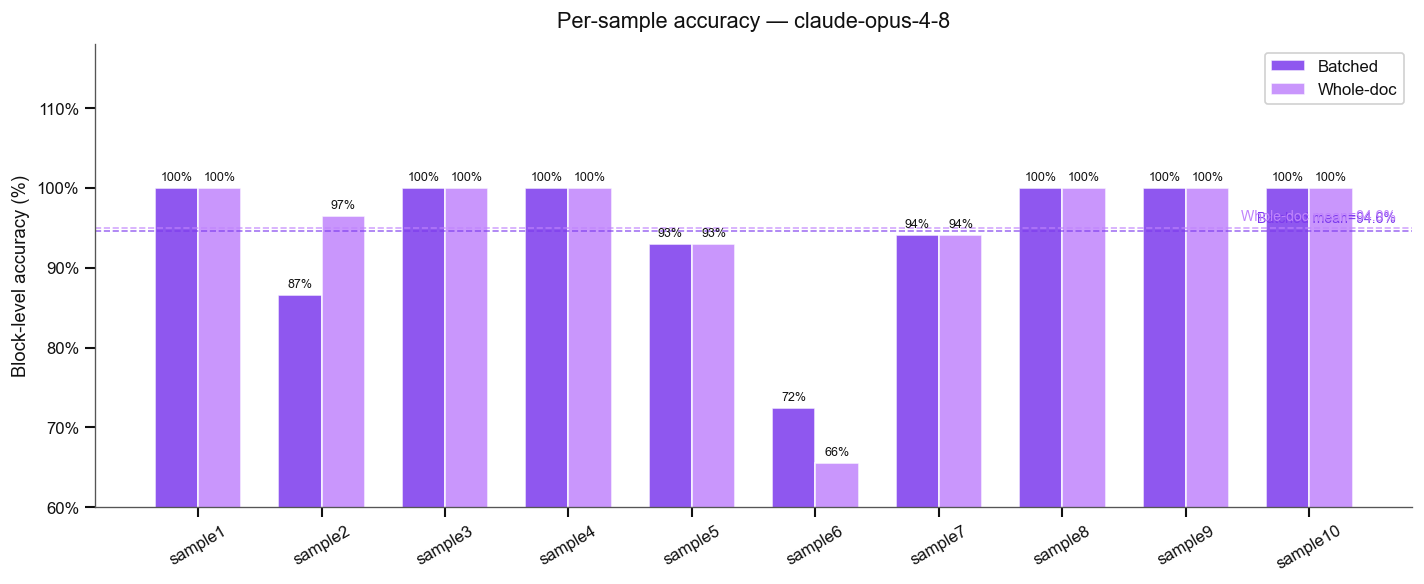

In [4]:
samples_ordered = df_b["sample"].tolist()
x = range(len(samples_ordered))

if WHOLEDOC_AVAILABLE:
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    acc_b = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    acc_w = df_w.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    bars_b = ax.bar([xi - w/2 for xi in x], acc_b, width=w,
                    label="Batched", color=COLOR_BATCH, alpha=0.85, edgecolor="white")
    bars_w = ax.bar([xi + w/2 for xi in x], acc_w, width=w,
                    label="Whole-doc", color=COLOR_WHOLE, alpha=0.85, edgecolor="white")
    for bar, v in list(zip(bars_b, acc_b)) + list(zip(bars_w, acc_w)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5)
    avg_b, avg_w = acc_b.mean(), acc_w.mean()
    ax.axhline(avg_b, color=COLOR_BATCH, linestyle="--", linewidth=1.0, alpha=0.7)
    ax.axhline(avg_w, color=COLOR_WHOLE, linestyle="--", linewidth=1.0, alpha=0.7)
    ax.text(len(x)-0.3, avg_b+0.6, f"Batched mean={avg_b:.1f}%",
            ha="right", va="bottom", fontsize=8.5, color=COLOR_BATCH)
    ax.text(len(x)-0.3, avg_w+0.6, f"Whole-doc mean={avg_w:.1f}%",
            ha="right", va="bottom", fontsize=8.5, color=COLOR_WHOLE)
    ax.legend(framealpha=0.9)
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    acc_b = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    colors = [COLOR_BATCH if v >= 95 else "#f59e0b" if v >= 85 else "#dc2626" for v in acc_b]
    bars = ax.bar(samples_ordered, acc_b, color=colors, width=0.6, edgecolor="white")
    for bar, v in zip(bars, acc_b):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    avg_b = acc_b.mean()
    ax.axhline(avg_b, color="#444", linestyle="--", linewidth=1.0)
    ax.text(len(x)-0.45, avg_b+0.7, f"Mean={avg_b:.1f}%",
            ha="right", va="bottom", fontsize=9.5, color="#444")

ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
ax.set_ylim(60, 118); ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy — {MODEL_NAME}", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine(); plt.tight_layout(); plt.show()

## 3 — Confusion matrix

Read **row by row**: each row = a true label, each column = what the model predicted.  
A perfect model has all mass on the diagonal.  
The most common failure mode is  being confused with  — both appear in the middle of a section and look like funder instructions.

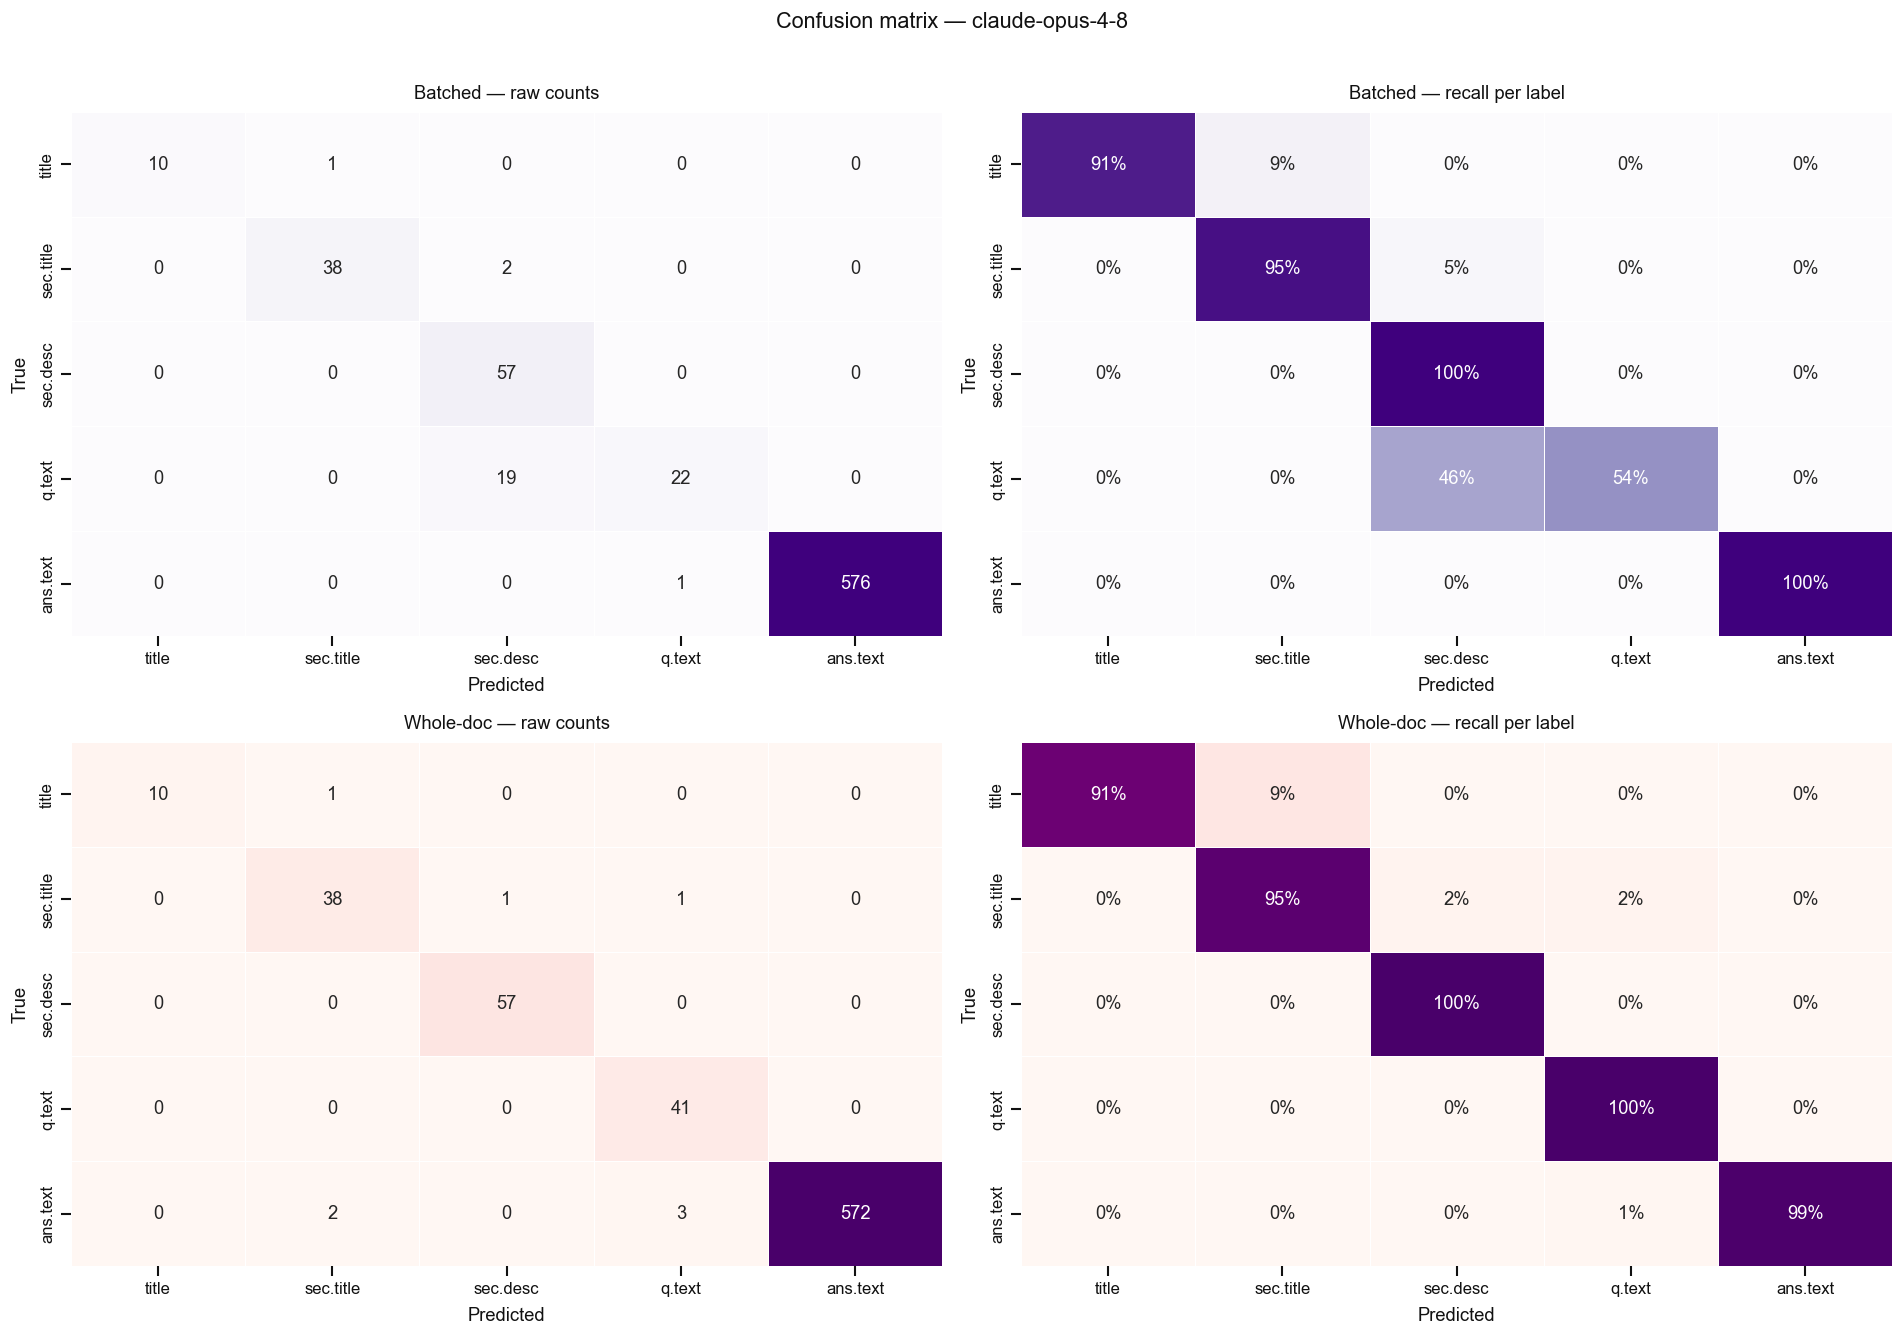

In [5]:
def conf_to_df(conf):
    m = pd.DataFrame(
        [[conf.get(t, {}).get(p, 0) for p in LABELS] for t in LABELS],
        index=SHORT, columns=SHORT)
    return m, m.div(m.sum(axis=1).replace(0, 1), axis=0)

mat_b, mat_bn = conf_to_df(conf_b)

if WHOLEDOC_AVAILABLE:
    mat_w, mat_wn = conf_to_df(conf_w)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    panels = [
        (axes[0,0], mat_b,  "d",   CMAP_BATCH, "Batched — raw counts"),
        (axes[0,1], mat_bn, ".0%", CMAP_BATCH, "Batched — recall per label"),
        (axes[1,0], mat_w,  "d",   CMAP_WHOLE, "Whole-doc — raw counts"),
        (axes[1,1], mat_wn, ".0%", CMAP_WHOLE, "Whole-doc — recall per label"),
    ]
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    panels = [
        (axes[0], mat_b,  "d",   CMAP_BATCH, "Raw counts"),
        (axes[1], mat_bn, ".0%", CMAP_BATCH, "Recall per label (row-normalised)"),
    ]

for ax, mat, fmt, cmap, title in panels:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, linewidths=0.6,
                linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11},
                vmin=(0 if fmt == ".0%" else None), vmax=(1 if fmt == ".0%" else None))
    ax.set_title(title, pad=8, fontsize=11)
    ax.set_xlabel("Predicted", labelpad=6)
    ax.set_ylabel("True", labelpad=6)

plt.suptitle(f"Confusion matrix — {MODEL_NAME}", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 4 — Precision / Recall / F1 per label

F1 balances precision and recall. Values below 80% on a label indicate a reliability risk for the pipeline.  
The delta table at the bottom shows per-label gain from whole-doc context — this is the clearest signal for deciding which strategy to use in production.

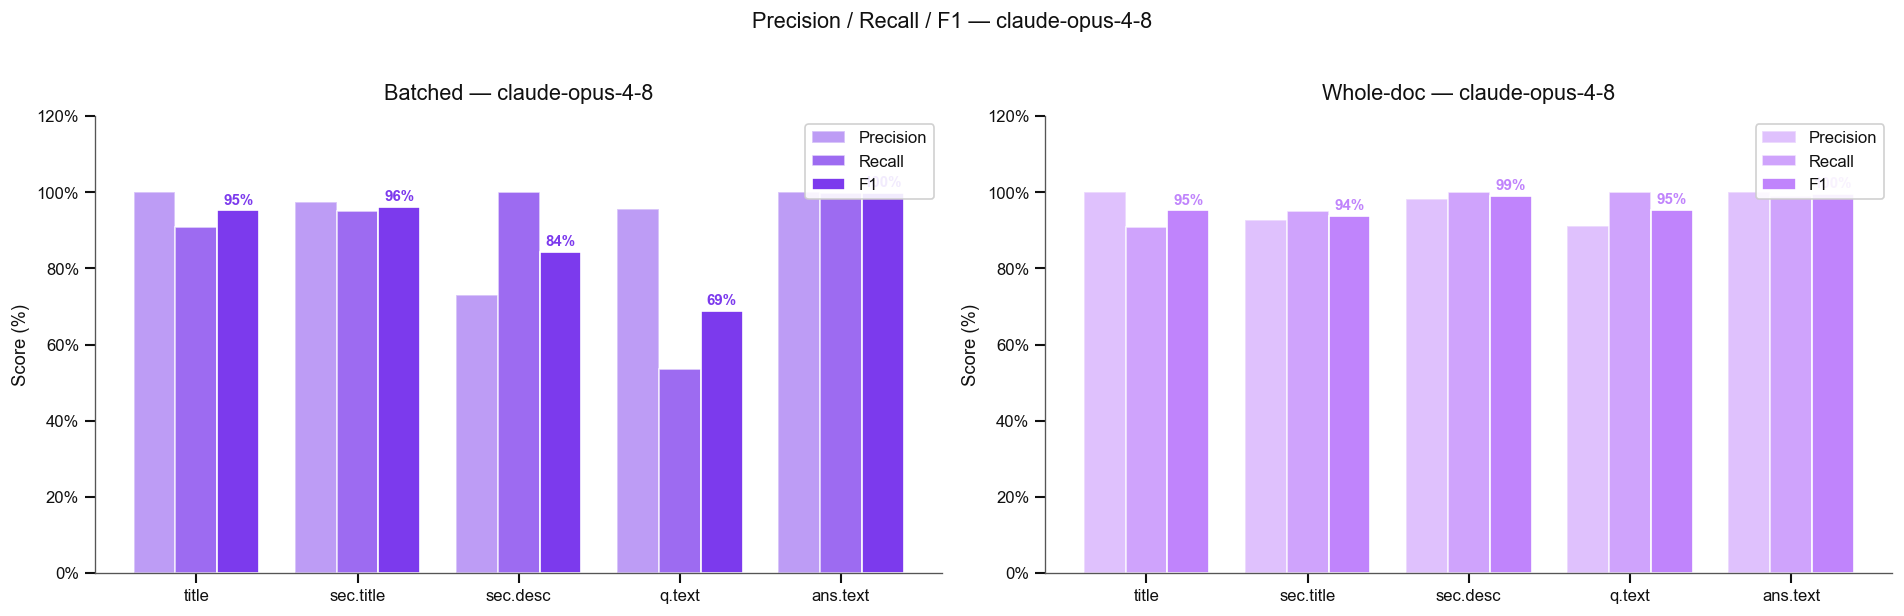

,f1_batch,f1_whole,delta
label,,,
title,95.2%,95.2%,0.0%
section.title,96.2%,93.8%,-2.4%
section.description,84.4%,99.1%,14.7%
question.text,68.8%,95.3%,26.6%
answer.text,99.9%,99.6%,-0.3%


In [6]:
df_f1_b = compute_f1_rows(conf_b)

if WHOLEDOC_AVAILABLE:
    df_f1_w = compute_f1_rows(conf_w)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    panels = [(axes[0], df_f1_b, COLOR_BATCH, f"Batched — {MODEL_NAME}"),
              (axes[1], df_f1_w, COLOR_WHOLE, f"Whole-doc — {MODEL_NAME}")]
else:
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))
    panels = [(axes, df_f1_b, COLOR_BATCH, f"Batched — {MODEL_NAME}")]

for ax, df_f1, color, title in panels:
    xi, w = range(len(LABELS)), 0.26
    ax.bar([i - w for i in xi], df_f1["precision"]*100, width=w, label="Precision",
           color=color, alpha=0.5, edgecolor="white")
    ax.bar([i     for i in xi], df_f1["recall"]*100,    width=w, label="Recall",
           color=color, alpha=0.75, edgecolor="white")
    bars = ax.bar([i + w for i in xi], df_f1["f1"]*100, width=w, label="F1",
                  color=color, edgecolor="white")
    for bar, row in zip(bars, df_f1.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f"{row.f1*100:.0f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
    ax.set_ylim(0, 120); ax.set_ylabel("Score (%)")
    ax.set_title(title, pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(loc="upper right", framealpha=0.9)
    sns.despine(ax=ax)

plt.suptitle(f"Precision / Recall / F1 — {MODEL_NAME}", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

if WHOLEDOC_AVAILABLE:
    comb = df_f1_b.set_index("label")[["f1"]].rename(columns={"f1":"f1_batch"}).join(
           df_f1_w.set_index("label")[["f1"]].rename(columns={"f1":"f1_whole"}))
    comb["delta"] = comb["f1_whole"] - comb["f1_batch"]
    display(comb.style.format("{:.1%}").background_gradient(subset=["f1_batch","f1_whole"], cmap="Blues"))

## 5 — Mislabeled blocks

Use this table to distinguish **systematic** errors (same true→pred pair, many blocks) from **isolated** ones.  
Systematic patterns → prompt or strategy needs fixing. Isolated → acceptable noise.

In [7]:
def error_breakdown(df_err, label):
    print(f"  {label}: {len(df_err)} mislabeled blocks")
    if df_err.empty:
        print("  No errors.\n"); return
    bd = (df_err.groupby(["true","pred"]).size()
          .reset_index(name="count").sort_values("count", ascending=False))
    print(bd.to_string(index=False)); print()

error_breakdown(errs_b, f"Batched — {MODEL_NAME}")
if WHOLEDOC_AVAILABLE:
    error_breakdown(errs_w, f"Whole-doc — {MODEL_NAME}")

  Batched — claude-opus-4-8: 26 mislabeled blocks
         true                pred  count
question.text section.description     19
     no_match         answer.text      3
section.title section.description      2
  answer.text       question.text      1
        title       section.title      1

  Whole-doc — claude-opus-4-8: 11 mislabeled blocks
         true                pred  count
  answer.text       question.text      3
     no_match       section.title      3
  answer.text       section.title      2
section.title       question.text      1
section.title section.description      1
        title       section.title      1



In [8]:
pd.set_option("display.max_colwidth", 100)
if not errs_b.empty:
    print("=== Batched errors ===")
    display(errs_b[["sample","page","true","pred","text"]])
if WHOLEDOC_AVAILABLE and not errs_w.empty:
    print("\n=== Whole-doc errors ===")
    display(errs_w[["sample","page","true","pred","text"]])

=== Batched errors ===


,sample,page,true,pred,text
0,sample2,2,question.text,section.description,"This should include, where appropriate:"
1,sample2,2,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who may access the data
2,sample2,2,question.text,section.description,and under what conditions;
3,sample2,2,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum length of time the data
4,sample2,2,question.text,section.description,will be available and any anticipated delay to data access after research findings are published;
5,sample2,2,question.text,section.description,"any special requirements for data sharing, for example, proprietary software needed to access"
6,sample2,2,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use and re-distribution,..."
7,sample2,2,question.text,section.description,"for the production of derivatives, including guidance for how data and data products should be"
8,sample2,2,question.text,section.description,cited;
9,sample2,2,question.text,section.description,"any resources and capabilities (equipment, connections, systems, software, expertise, etc.)"



=== Whole-doc errors ===


,sample,page,true,pred,text
0,sample2,1,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp with help from the"
1,sample2,2,section.title,question.text,preservation;
2,sample2,4,answer.text,question.text,Data Repositories. Senior investigators typically archive relevant data using their own group se...
3,sample2,4,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers should not prohibit their"
4,sample2,5,section.title,section.description,data.
5,sample6,1,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, 2, 3, and 4"
6,sample6,1,no_match,section.title,2. Data and metadata standards. The PI’s research group will adopt the longstanding
7,sample6,1,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to request data and codes at
8,sample6,1,no_match,section.title,"4. Policies and provisions for re-use, re-distribution. Simulation data will in essence grow to"
9,sample6,1,no_match,section.title,5. Plans for archiving and preservation of access. Local data will be archived on the group’s


---

## 6 — Option A: PDF Direct

Instead of using pdfplumber to extract text blocks, the raw PDF is sent directly to Claude.  
Claude sees the actual visual layout (fonts, indentation, columns) and both **extracts and classifies** the document in a single API call.

**Key difference:** Claude produces paragraph-level blocks (~27% of the pdfplumber count).  
Bounding boxes are not available — this approach cannot drive the viewer overlay.

**Regenerate:** `dmpbridge-pdf --model claude-opus-4-8`

In [9]:
if PDF_AVAILABLE:
    # ── Accuracy + block count comparison ────────────────────────────────────
    print("=== Strategy comparison ===\n")
    rows_cmp = [
        ("Batch",       df_b, tn_b),
        ("Whole-doc",   df_w, tn_b),
        ("PDF-direct",  df_p, tn_p),
    ]
    hdr = f"  {'Strategy':<14}  {'Blocks':>8}  {'Correct':>8}  {'Accuracy':>9}"
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    for label, df, tn in rows_cmp:
        tc = int(df["correct"].sum())
        tn_ = int(df["total"].sum())
        print(f"  {label:<14}  {tn_:>8}  {tc:>8}  {tc/tn_*100:>8.1f}%")

    # ── Block count per sample ────────────────────────────────────────────────
    print("\n=== Block count per sample ===\n")
    hdr2 = f"  {'Sample':<12}  {'Batch/WD':>9}  {'PDF-direct':>11}  {'Ratio':>7}"
    print(hdr2)
    print("  " + "-" * (len(hdr2) - 2))
    for _, rb in df_b.iterrows():
        s   = rb["sample"]
        nb  = int(rb["total"])
        rp  = df_p[df_p["sample"] == s]
        np_ = int(rp["total"].iloc[0]) if not rp.empty else 0
        print(f"  {s:<12}  {nb:>9}  {np_:>11}  {np_/nb*100:>6.0f}%")
    print("  " + "-" * (len(hdr2) - 2))
    print(f"  {'TOTAL':<12}  {tn_b:>9}  {tn_p:>11}  {tn_p/tn_b*100:>6.0f}%")
else:
    print("PDF-direct data not available — run: dmpbridge-pdf --model", MODEL_DISPLAY)

=== Strategy comparison ===

  Strategy          Blocks   Correct   Accuracy
  ---------------------------------------------
  Batch                741       703      94.9%
  Whole-doc            741       718      96.9%
  PDF-direct           203       193      95.1%

=== Block count per sample ===

  Sample         Batch/WD   PDF-direct    Ratio
  ---------------------------------------------
  sample1              78           32      41%
  sample2             172           42      24%
  sample3              69           23      33%
  sample4              78           15      19%
  sample5              86           28      33%
  sample6              29           11      38%
  sample7              17            2      12%
  sample8              59           19      32%
  sample9              85           14      16%
  sample10             68           17      25%
  ---------------------------------------------
  TOTAL               741          203      27%


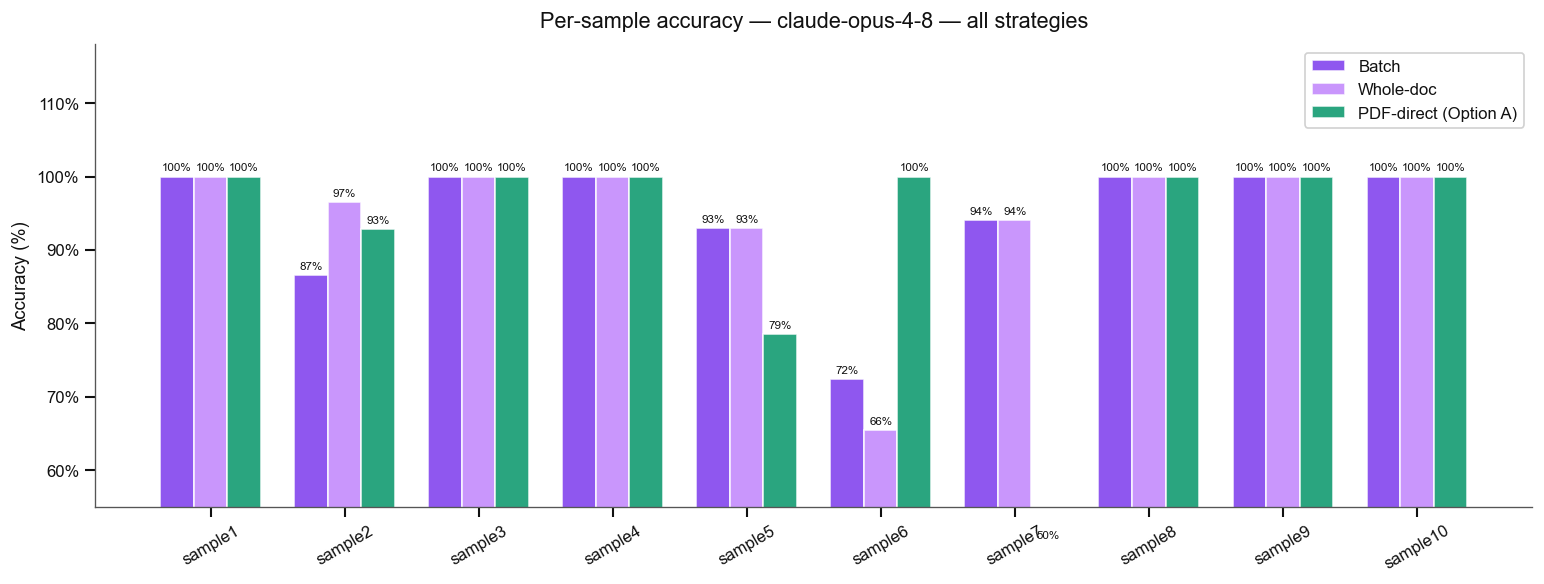

In [10]:
if PDF_AVAILABLE:
    # ── Per-sample accuracy — all 3 strategies side by side ──────────────────
    samples_ordered = df_b["sample"].tolist()
    x = range(len(samples_ordered))
    w = 0.25

    acc_b_ = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    acc_w_ = df_w.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    acc_p_ = df_p.set_index("sample").loc[samples_ordered, "accuracy"] * 100

    fig, ax = plt.subplots(figsize=(13, 5))
    for offset, acc, color, label in [
        (-w,   acc_b_, COLOR_BATCH, "Batch"),
        (0,    acc_w_, COLOR_WHOLE, "Whole-doc"),
        (+w,   acc_p_, COLOR_PDF,   "PDF-direct (Option A)"),
    ]:
        bars = ax.bar([xi + offset for xi in x], acc, width=w,
                      label=label, color=color, alpha=0.85, edgecolor="white")
        for bar, v in zip(bars, acc):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.0f}%", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
    ax.set_ylim(55, 118); ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"Per-sample accuracy — {MODEL_NAME} — all strategies", pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(framealpha=0.9); sns.despine(); plt.tight_layout(); plt.show()

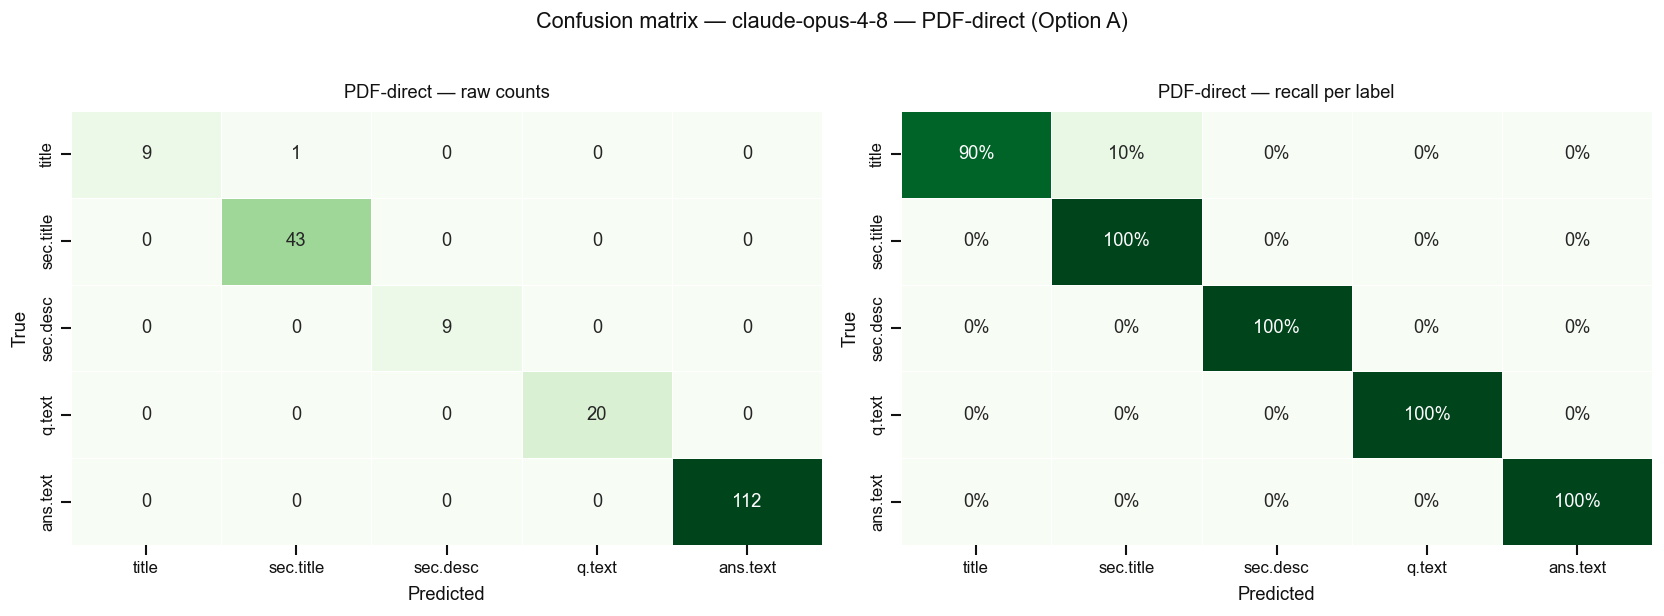

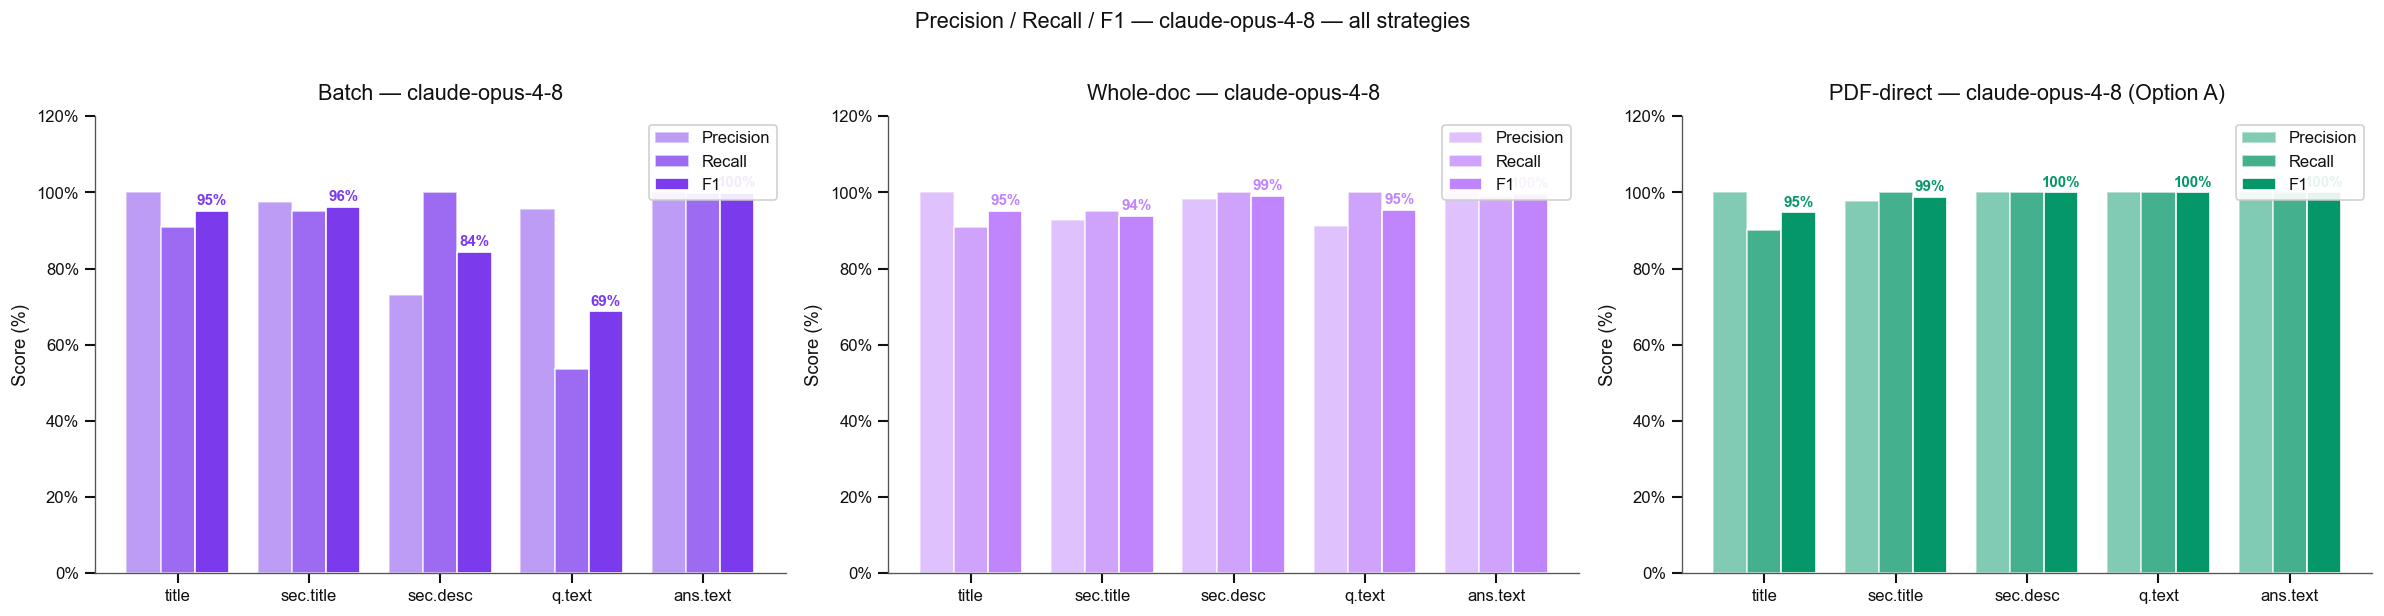

,f1_whole,f1_pdf,delta (pdf − whole)
label,,,
title,95.2%,94.7%,-0.5%
section.title,93.8%,98.9%,5.0%
section.description,99.1%,100.0%,0.9%
question.text,95.3%,100.0%,4.7%
answer.text,99.6%,100.0%,0.4%


In [11]:
if PDF_AVAILABLE:
    # ── Confusion matrix + F1 for PDF-direct ────────────────────────────────
    mat_p, mat_pn = conf_to_df(conf_p)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mat, fmt, title in [
        (axes[0], mat_p,  "d",   "PDF-direct — raw counts"),
        (axes[1], mat_pn, ".0%", "PDF-direct — recall per label"),
    ]:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap=CMAP_PDF, linewidths=0.6,
                    linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11},
                    vmin=(0 if fmt == ".0%" else None), vmax=(1 if fmt == ".0%" else None))
        ax.set_title(title, pad=8, fontsize=11)
        ax.set_xlabel("Predicted", labelpad=6); ax.set_ylabel("True", labelpad=6)

    plt.suptitle(f"Confusion matrix — {MODEL_NAME} — PDF-direct (Option A)", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    # ── F1 bar chart — all 3 strategies ──────────────────────────────────────
    df_f1_b_ = compute_f1_rows(conf_b)
    df_f1_w_ = compute_f1_rows(conf_w)
    df_f1_p  = compute_f1_rows(conf_p)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, df_f1, color, title in [
        (axes[0], df_f1_b_, COLOR_BATCH, f"Batch — {MODEL_NAME}"),
        (axes[1], df_f1_w_, COLOR_WHOLE, f"Whole-doc — {MODEL_NAME}"),
        (axes[2], df_f1_p,  COLOR_PDF,   f"PDF-direct — {MODEL_NAME} (Option A)"),
    ]:
        xi, bw = range(len(LABELS)), 0.26
        ax.bar([i - bw for i in xi], df_f1["precision"]*100, width=bw,
               label="Precision", color=color, alpha=0.5, edgecolor="white")
        ax.bar([i      for i in xi], df_f1["recall"]*100,    width=bw,
               label="Recall",    color=color, alpha=0.75, edgecolor="white")
        bars = ax.bar([i + bw for i in xi], df_f1["f1"]*100, width=bw,
                      label="F1", color=color, edgecolor="white")
        for bar, row in zip(bars, df_f1.itertuples()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                    f"{row.f1*100:.0f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color=color)
        ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
        ax.set_ylim(0, 120); ax.set_ylabel("Score (%)"); ax.set_title(title, pad=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
        ax.legend(loc="upper right", framealpha=0.9); sns.despine(ax=ax)

    plt.suptitle(f"Precision / Recall / F1 — {MODEL_NAME} — all strategies", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    # ── F1 delta table: PDF-direct vs whole-doc ───────────────────────────────
    comb = df_f1_w_.set_index("label")[["f1"]].rename(columns={"f1":"f1_whole"}).join(
           df_f1_p.set_index("label")[["f1"]].rename(columns={"f1":"f1_pdf"}))
    comb["delta (pdf − whole)"] = comb["f1_pdf"] - comb["f1_whole"]
    display(comb.style.format("{:.1%}").background_gradient(subset=["f1_whole","f1_pdf"], cmap="Greens"))

In [12]:
if PDF_AVAILABLE:
    print("=== Mislabeled blocks — PDF-direct ===\n")
    error_breakdown(errs_p, f"PDF-direct — {MODEL_NAME}")

    if not errs_p.empty:
        pd.set_option("display.max_colwidth", 100)
        display(errs_p[["sample", "page", "true", "pred", "text"]])

=== Mislabeled blocks — PDF-direct ===

  PDF-direct — claude-opus-4-8: 1 mislabeled blocks
 true          pred  count
title section.title      1



,sample,page,true,pred,text
0,sample7,1,title,section.title,Resource/Data Sharing Plan
